In [1]:
pip install pandas numpy matplotlib statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv("airline-passengers.csv",
                 parse_dates=['Month'],
                 index_col='Month')

In [4]:
print("First 5 rows:")
print(df.head())

First 5 rows:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


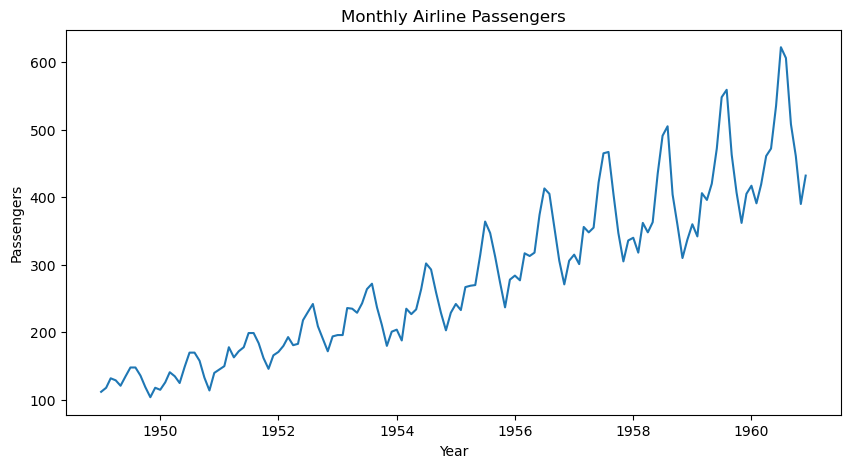

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Passengers'])
plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

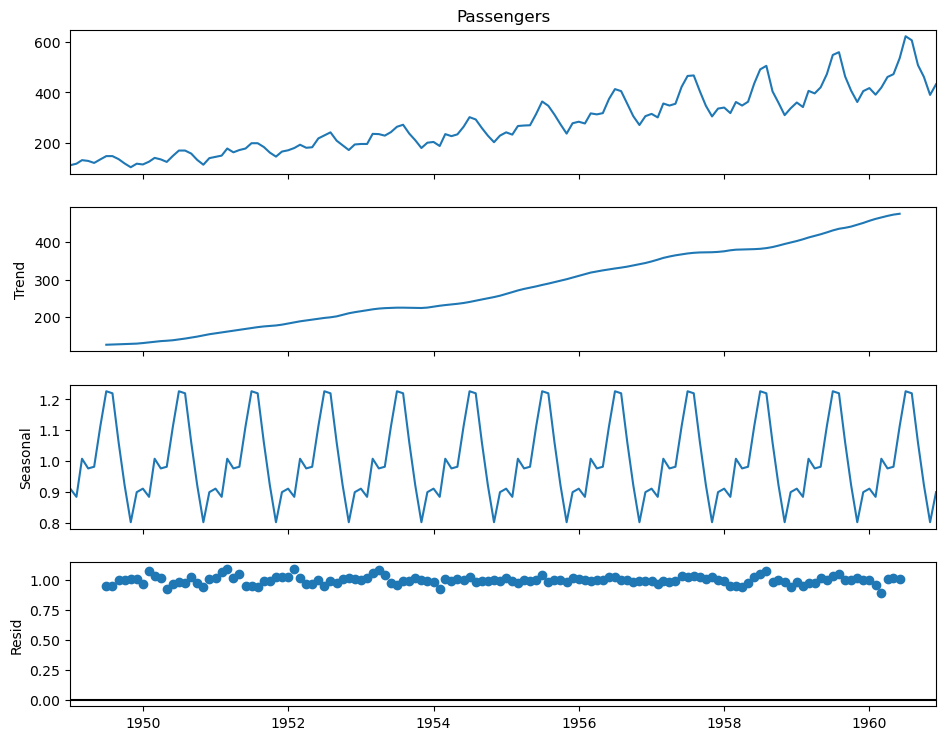

In [6]:
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')

fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

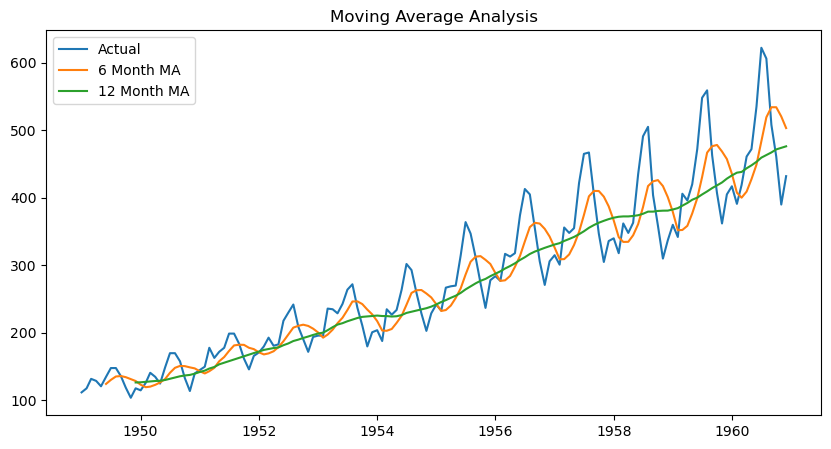

In [7]:
df['MA_6'] = df['Passengers'].rolling(window=6).mean()
df['MA_12'] = df['Passengers'].rolling(window=12).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label="Actual")
plt.plot(df['MA_6'], label="6 Month MA")
plt.plot(df['MA_12'], label="12 Month MA")
plt.legend()
plt.title("Moving Average Analysis")
plt.show()

In [8]:
train = df.iloc[:-6]
test = df.iloc[-6:]

In [9]:
model = ARIMA(train['Passengers'], order=(2,1,1))
result = model.fit()

D:\Users\Mukta\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Users\Mukta\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
D:\Users\Mukta\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [10]:
forecast = result.forecast(steps=6)

In [11]:
rmse = np.sqrt(mean_squared_error(test['Passengers'], forecast))
print("RMSE:", rmse)

RMSE: 60.16529261900851


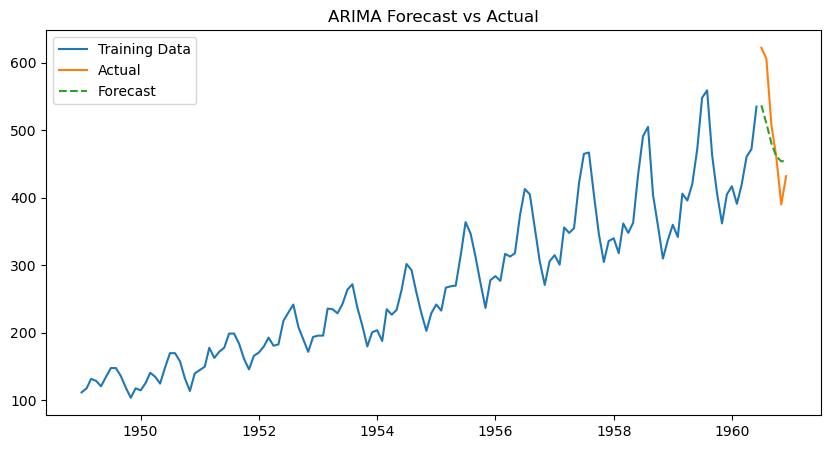

In [12]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train['Passengers'], label="Training Data")
plt.plot(test.index, test['Passengers'], label="Actual")
plt.plot(test.index, forecast, label="Forecast", linestyle="--")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()